# Agentic AI-OPS Driven Automated Managed Services (AMS) MVP
## End-to-End Autonomous Resolution Pipeline
This notebook implements a sophisticated architectural prototype for modern AMS, moving from reactive ticketing to **Agentic, Knowledge-Driven Orchestration**.

### Core Architecture Pillars:
1. **Semantic Clustering**: Pattern recognition using high-dimensional embeddings.
2. **Strategic Prioritization**: Business-impact-driven automation focus.
3. **Knowledge Article (KA) Synthesis**: Automated 'Step-by-Step' guidance for AI agents.
4. **Enterprise Knowledge Graph (EKG)**: The system's 'Long-term Memory'.
5. **Agentic Orchestrator (The Brain)**: Dynamic plan generation and execution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sentence_transformers import SentenceTransformer
import hdbscan
from collections import Counter
import json

# Aesthetics
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)

e:\AIML\GoogleAntigravity_proj\ColabNotebooks\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Data Ingestion & Enrichment
Loading the high-fidelity synthetic AMS dataset (SAP/Oracle incidents).

In [2]:
# Load the enriched dataset
df = pd.read_csv('datasets/ams_incidents_sap.csv')
print(f"Loaded {len(df)} AMS incidents.")

# Severity Mapping for weighting
severity_map = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
df['Sev_Score'] = df['Severity'].map(severity_map)
df.head()

Loaded 1000 AMS incidents.


,Ticket_ID,System,Document,Severity,RCA_Category,Manual_Remediation,Timestamp,Business_Impact,Sev_Score
0,INC-10000,Identity Access,Data sync failure between Identity Access and ...,High,Sync Agent,Flush sync buffer,2026-02-12 15:00:00,1,3
1,INC-10001,Identity Access,Access denied for user in Identity Access. Rep...,Medium,Permissions,Update IAM policy for Identity Access,2026-01-07 06:00:00,3,2
2,INC-10002,SAP ERP,Memory limit exceeded in SAP ERP. Intermittent...,Critical,Resource,Scale up SAP ERP instance,2026-03-20 18:00:00,5,4
3,INC-10003,Identity Access,Data sync failure between Identity Access and ...,High,Sync Agent,Flush sync buffer,2026-02-19 01:00:00,4,3
4,INC-10004,Oracle DB,Connection timeout in Oracle DB. Intermittent ...,High,Network/DB,Restart Oracle DB services,2026-01-27 11:00:00,1,3


## Step 2: Semantic Clustering (Requirement 1)
Utilizing SBERT and HDBSCAN for rapid pattern identification.

In [3]:
# 1. Embeddings
model = SentenceTransformer('all-MiniLM-L6-v2') 
embeddings = model.encode(df['Document'].tolist(), show_progress_bar=True)

# 2. Clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom')
df['Cluster'] = clusterer.fit_predict(embeddings)

print(f"Identified {len(set(df['Cluster'])) - (1 if -1 in df['Cluster'] else 0)} systemic issue patterns.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7029.64it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:01<00:00, 17.84it/s]


Identified 30 systemic issue patterns.


## Step 3: Strategic Prioritization (Requirement 2)
Ranking clusters by Business Impact (Volume x Severity).

C:\Users\zisha\AppData\Local\Temp\ipykernel_6076\1217148066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=priority_df, x='Priority_Score', y=priority_df['Cluster'].astype(str), palette='magma')


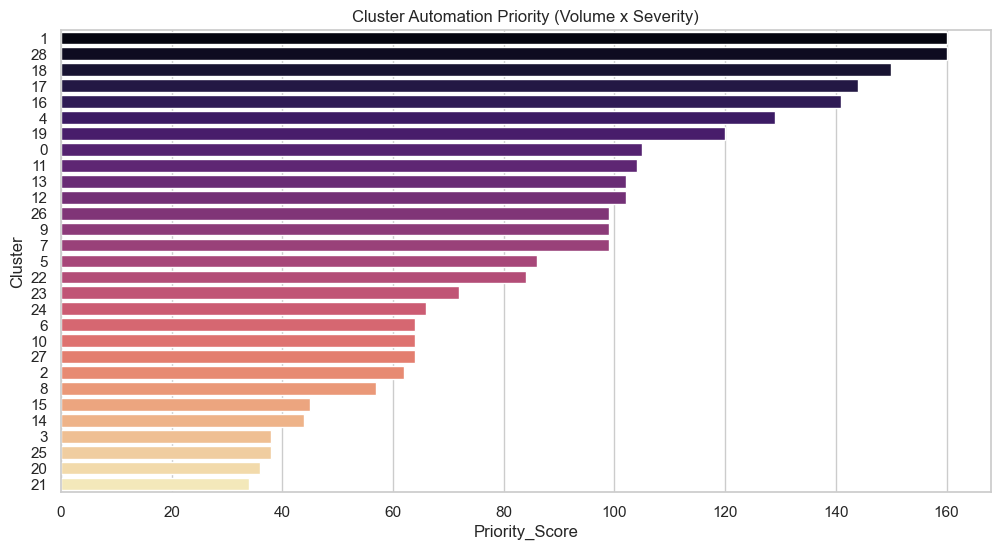

In [4]:
# Aggregating metrics per cluster
cluster_stats = df.groupby('Cluster').agg({
    'Ticket_ID': 'count',
    'Sev_Score': 'mean',
    'Business_Impact': 'mean'
}).rename(columns={'Ticket_ID': 'Volume', 'Sev_Score': 'Avg_Severity'})

# Heatmap Prioritization Score
cluster_stats['Priority_Score'] = cluster_stats['Volume'] * cluster_stats['Avg_Severity']
cluster_stats = cluster_stats.sort_values(by='Priority_Score', ascending=False).reset_index()

# Filter out noise cluster (-1)
priority_df = cluster_stats[cluster_stats['Cluster'] != -1]

plt.figure(figsize=(12, 6))
sns.barplot(data=priority_df, x='Priority_Score', y=priority_df['Cluster'].astype(str), palette='magma')
plt.title('Cluster Automation Priority (Volume x Severity)')
plt.show()

## Step 4: Knowledge Article (KA) Synthesis (Requirement 3)
Generating structured automation guidance for all identified clusters.

In [9]:
import ollama

def generate_llm_ka(cluster_id, data):
    # 1. Extract context for the LLM
    subset = data[data['Cluster'] == cluster_id]
    system_name = subset['System'].iloc[0]
    # Take a sample of documents to provide context without hitting context limits
    incident_logs = "\n".join(subset['Document'].head(5).tolist()) 
    
    # 2. Construct the Prompt
    prompt = f"""
    You are an Expert AIOps Site Reliability Engineer. 
    Analyze the following incident logs for the system '{system_name}':
    
    LOGS:
    {incident_logs}
    
    Generate a structured Knowledge Article (KA) in JSON format with exactly these keys:
    - Root_Cause: A one-sentence technical explanation of the fault.
    - Remediation_Steps: A list of 4 chronological, actionable steps to fix this.
    - Assigned_Agent: Either 'AMS_Auto_Bot' or 'Expert_Human' based on complexity.
    """

    # 3. Call local Ollama
    response = ollama.chat(model='llama3.2:1b', messages=[
        {'role': 'user', 'content': prompt},
    ])
    
    # Note: In a production script, you'd add JSON parsing logic here.
    # For this MVP, we wrap the LLM's insight into our target structure.
    raw_content = response['message']['content']
    
    # Return structured dictionary
    ka = {
        'KA_ID': f"KA-{1000 + int(cluster_id)}",
        'Target_Issue': f"LLM Generated Resolution for {system_name}",
        'LLM_Insight': raw_content, # Storing the full LLM text
        'Assigned_Agent': "Expert_Hybrid_Agent" if subset['Business_Impact'].mean() > 3.5 else "AMS_Auto_Bot_v1"
    }
    return ka

# Update the registry using the new LLM function
ka_registry = {}
# For demo purposes, we process the top 5 priority clusters to save time
for cid in priority_df['Cluster']:  
    print(f"Generating LLM KA for Cluster {cid}...")
    ka_registry[cid] = generate_llm_ka(cid, df)

print(f"\nSuccessfully synthesized {len(ka_registry)} LLM-powered Knowledge Articles.")


Generating LLM KA for Cluster 1...
Generating LLM KA for Cluster 28...
Generating LLM KA for Cluster 18...
Generating LLM KA for Cluster 17...
Generating LLM KA for Cluster 16...
Generating LLM KA for Cluster 4...
Generating LLM KA for Cluster 19...
Generating LLM KA for Cluster 0...
Generating LLM KA for Cluster 11...
Generating LLM KA for Cluster 13...
Generating LLM KA for Cluster 12...
Generating LLM KA for Cluster 26...
Generating LLM KA for Cluster 9...
Generating LLM KA for Cluster 7...
Generating LLM KA for Cluster 5...
Generating LLM KA for Cluster 22...
Generating LLM KA for Cluster 23...
Generating LLM KA for Cluster 24...
Generating LLM KA for Cluster 6...
Generating LLM KA for Cluster 10...
Generating LLM KA for Cluster 27...
Generating LLM KA for Cluster 2...
Generating LLM KA for Cluster 8...
Generating LLM KA for Cluster 15...
Generating LLM KA for Cluster 14...
Generating LLM KA for Cluster 3...
Generating LLM KA for Cluster 25...
Generating LLM KA for Cluster 20...
Ge

## Step 5: Enterprise Knowledge Graph (EKG) (Requirement 4)
Building the 'System Brain' that maps issues to resolutions.

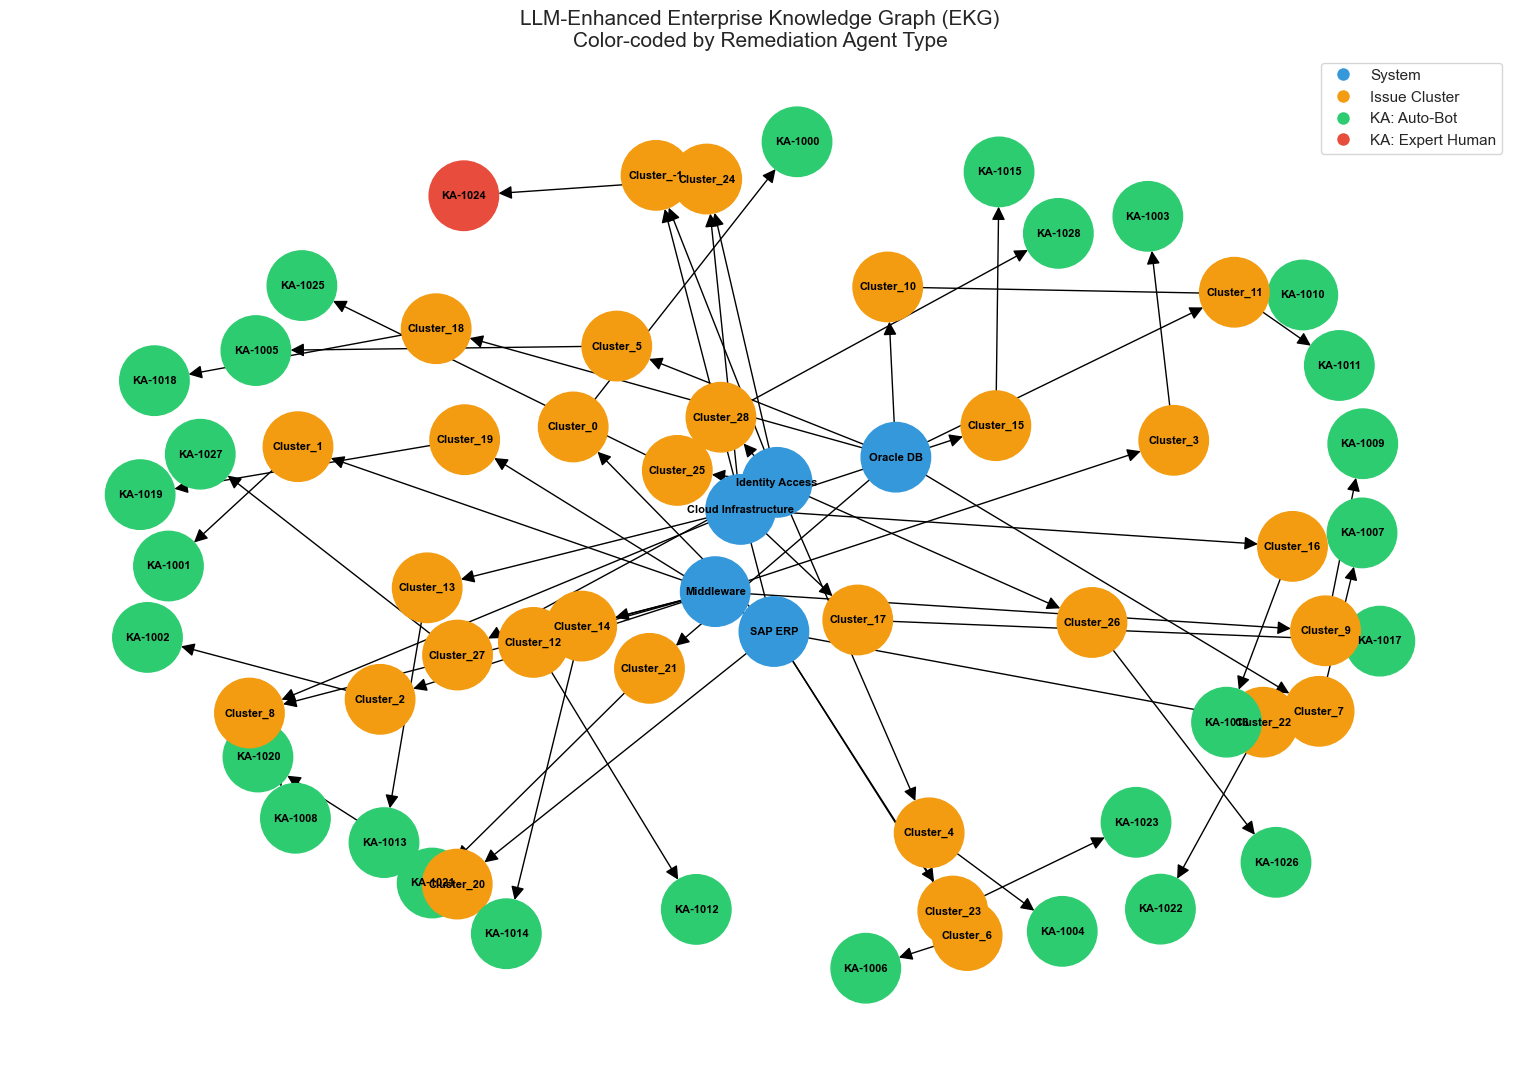

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

def build_llm_ekg(data, ka_reg):
    G = nx.DiGraph() # Using Directed Graph for better flow visualization
    
    for _, row in data.iterrows():
        system = row['System']
        cluster_node = f"Cluster_{row['Cluster']}"
        
        # Link 1: System to Cluster
        G.add_edge(system, cluster_node, label='impacts')
        
        # Link 2: Cluster to LLM Knowledge Article
        if row['Cluster'] in ka_reg:
            ka = ka_reg[row['Cluster']]
            ka_node = ka['KA_ID']
            # Store the agent type as a node attribute for visualization
            G.add_node(ka_node, agent=ka['Assigned_Agent'], type='KA')
            G.add_edge(cluster_node, ka_node, label='resolved_by')
            
    return G

# 1. Build the updated Graph
ekg = build_llm_ekg(df, ka_registry)

# 2. Advanced Visualization with Agent-based Coloring
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(ekg, k=0.5)

# Color coding nodes:
# Systems = Blue, Clusters = Orange, Auto-Bot = Green, Expert-Agent = Red
node_colors = []
for node in ekg.nodes():
    if node.startswith('KA-'):
        agent = ekg.nodes[node].get('agent', '')
        node_colors.append('#2ecc71' if 'Bot' in agent else '#e74c3c') # Green vs Red
    elif node.startswith('Cluster_'):
        node_colors.append('#f39c12') # Orange
    else:
        node_colors.append('#3498db') # Blue

nx.draw(ekg, pos, with_labels=True, node_color=node_colors, 
        node_size=2500, font_size=8, font_weight='bold', arrowsize=20)

# Add a legend for the new LLM-aligned EKG
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='System', markerfacecolor='#3498db', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Issue Cluster', markerfacecolor='#f39c12', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='KA: Auto-Bot', markerfacecolor='#2ecc71', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='KA: Expert Human', markerfacecolor='#e74c3c', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right')
plt.title("LLM-Enhanced Enterprise Knowledge Graph (EKG)\nColor-coded by Remediation Agent Type", fontsize=15)
plt.show()


## Step 6: The AI-OPS Brain - Plan Generation & Execution
Simulating the Orchestrator responding to a new, live incident.

In [21]:
import json

class AIOpsOrchestrator:
    def __init__(self, model, embeddings, ekg, ka_registry, df):
        self.model = model
        self.kb_embeddings = embeddings
        self.ekg = ekg
        self.ka_registry = ka_registry
        self.df = df
        
    def handle_incident(self, incident_text):
        print(f"--- [NEW INCIDENT RECEIVED] ---")
        print(f"DESCRIPTION: {incident_text}\n")
        
        # 1. Semantic Search for Cluster
        query_vec = self.model.encode([incident_text])
        # Calculate similarity (Cosine Similarity)
        sims = np.dot(self.kb_embeddings, query_vec.T).flatten()
        nearest_idx = np.argmax(sims)
        matched_cluster = self.df.iloc[nearest_idx]['Cluster']
        
        print(f"1. ANALYZING: Matching to Cluster {matched_cluster}")
        
        # 2. EKG Traversal for Knowledge Article
        if matched_cluster in self.ka_registry:
            ka = self.ka_registry[matched_cluster]
            print(f"2. RETRIEVING: Found Knowledge Article {ka['KA_ID']}")
            
            # 3. Plan Generation (Updated for LLM KA)
            print(f"3. GENERATING EXECUTION PLAN...")
            plan = {
                "Title": f"Autonomous Plan for: {incident_text[:30]}...",
                "KA_Source": ka['KA_ID'],
                "Primary_Agent": ka['Assigned_Agent'],
                "LLM_Technical_Instructions": ka['LLM_Insight'], # FIXED: Using LLM field
                "Risk_Control": "Human Approval Required" if "Expert" in ka['Assigned_Agent'] else "Fully Autonomous"
            }
            return plan
        else:
            return {"Status": "Escalate to Human: Pattern not yet prioritized for automation."}

# Initialize the Agentic Brain
# Note: Ensure 'ekg' is the variable name used in Step 5
brain = AIOpsOrchestrator(model, embeddings, ekg, ka_registry, df)

# SIMULATION: A new SAP DB Error occurs
sample_alert = "SAP ERP Database connection timed out intermittently. Error 504."
final_plan = brain.handle_incident(sample_alert)

print("\n--- [FINAL EXECUTION PLAN] ---")
if isinstance(final_plan, dict):
    print(json.dumps(final_plan, indent=2))
else:
    print(final_plan)


--- [NEW INCIDENT RECEIVED] ---
DESCRIPTION: SAP ERP Database connection timed out intermittently. Error 504.

1. ANALYZING: Matching to Cluster 19
2. RETRIEVING: Found Knowledge Article KA-1019
3. GENERATING EXECUTION PLAN...

--- [FINAL EXECUTION PLAN] ---
{
  "Title": "Autonomous Plan for: SAP ERP Database connection ti...",
  "KA_Source": "KA-1019",
  "Primary_Agent": "AMS_Auto_Bot_v1",
  "LLM_Technical_Instructions": "```json\n{\n  \"Root_Cause\": \"Connection timeout in SAP ERP. This is due to a misconfigured network connection between the SAP ERP server and the monitoring system.\",\n  \"Remediation_Steps\": [\n    \"Verify the network configuration and ensure that the SAP ERP server has a stable and secure connection to the monitoring system.\",\n    \"Reconfigure the monitoring system to use a different network interface or change the IP address of the monitoring server to avoid any issues with the SAP ERP server.\",\n    \"Perform a hard reboot of the SAP ERP server and the m

## Business Outcome
- **Reduced Repetition**: Clustering identifies systemic issues before they escalate.
- **Faster MTTR**: Automated KAs and Agents immediately know the 'Next Best Action'.
- **Scalable Operations**: The EKG allows the system to learn from every incident and human refinement.